<a href="https://colab.research.google.com/github/kirtichaudhari1506-ui/Machine-Learning-Practicals/blob/main/Practical2_Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
Student Name : Kirti Mukesh Chaudhari
Div : A
Practical Batch : A-1
Roll No : 25
Date : 16/09/2026

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("advertising.csv")

df.head()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad
0,68.95,35,61833.90,256.09,Cloned 5thgeneration orchestration,Wrightburgh,0,Tunisia,27-03-2016 00:53,0
1,80.23,31,68441.85,193.77,Monitored national standardization,West Jodi,1,Nauru,04-04-2016 01:39,0
2,69.47,26,59785.94,236.50,Organic bottom-line service-desk,Davidton,0,San Marino,13-03-2016 20:35,0
3,74.15,29,54806.18,245.89,Triple-buffered reciprocal time-frame,West Terrifurt,1,Italy,10-01-2016 02:31,0
4,68.37,35,73889.99,225.58,Robust logistical utilization,South Manuel,0,Iceland,03-06-2016 03:36,0


In [4]:
print("Shape of dataset:", df.shape)

print("\nColumn names:")
print(df.columns)

print("\nDataset information:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

print("\nStatistical information:")
print(df.describe(exclude='object'))

print("\nTarget class distribution:")
print(df["Clicked on Ad"].value_counts())

Shape of dataset: (1000, 10)

Column names:
Index(['Daily Time Spent on Site', 'Age', 'Area Income',
       'Daily Internet Usage', 'Ad Topic Line', 'City', 'Male', 'Country',
       'Timestamp', 'Clicked on Ad'],
      dtype='object')

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Daily Time Spent on Site  1000 non-null   float64
 1   Age                       1000 non-null   int64  
 2   Area Income               1000 non-null   float64
 3   Daily Internet Usage      1000 non-null   float64
 4   Ad Topic Line             1000 non-null   object 
 5   City                      1000 non-null   object 
 6   Male                      1000 non-null   int64  
 7   Country                   1000 non-null   object 
 8   Timestamp                 1000 non-null   object 
 9   Clicked on Ad             

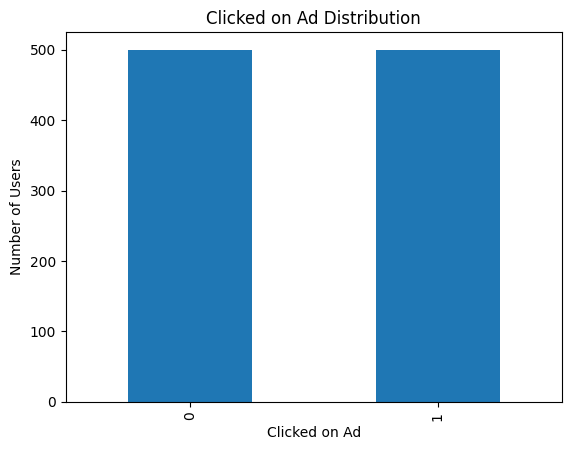

In [5]:
click_ad = df["Clicked on Ad"].value_counts()

click_ad.plot(kind="bar")

plt.title("Clicked on Ad Distribution")
plt.xlabel("Clicked on Ad")
plt.ylabel("Number of Users")
plt.show()

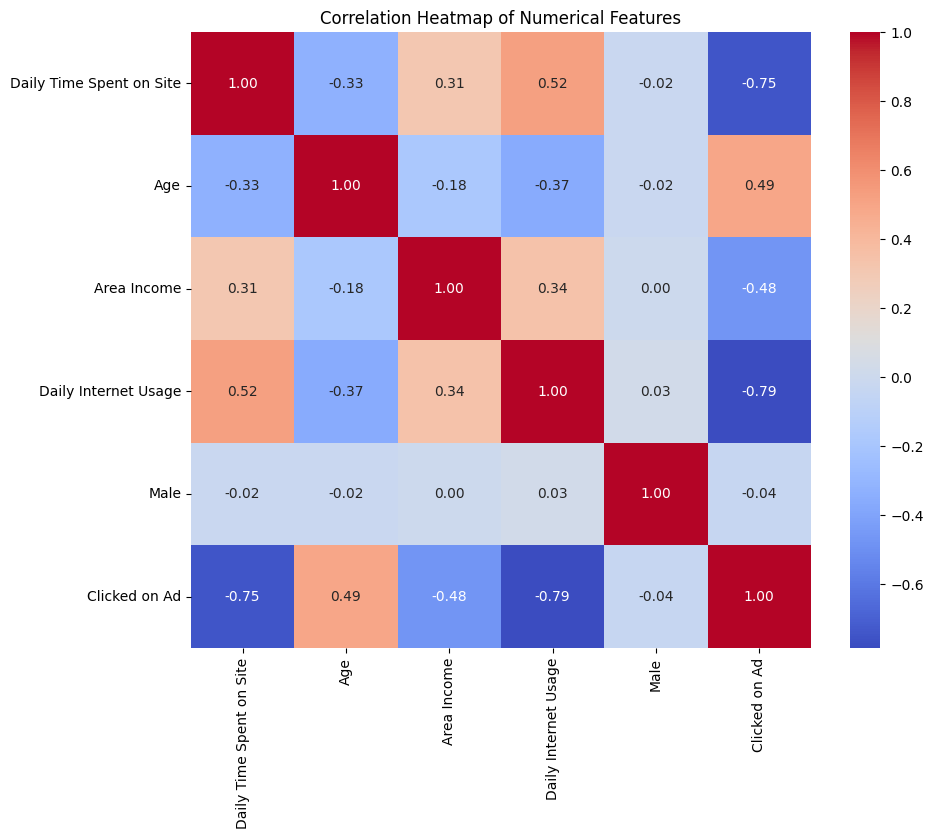

In [6]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    df.select_dtypes(include=['float64', 'int64']).corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap of Numerical Features")
plt.show()

In [7]:
X = df[["Daily Time Spent on Site", "Daily Internet Usage"]]

y = df["Clicked on Ad"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   Daily Time Spent on Site  Daily Internet Usage
0                     68.95                256.09
1                     80.23                193.77
2                     69.47                236.50
3                     74.15                245.89
4                     68.37                225.58

Target:
0    0
1    0
2    0
3    0
4    0
Name: Clicked on Ad, dtype: int64


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (800, 2)
Testing data: (200, 2)


In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print(X_test_scaled)

[[-1.48770037 -1.17503807]
 [ 0.48919573  1.37582021]
 [ 1.49722326  0.71874287]
 [ 0.56877685  0.68835647]
 [-1.35253878 -0.22666255]
 [-1.25337818 -1.1044411 ]
 [ 0.26434748 -1.2933851 ]
 [ 0.15760773 -1.21570559]
 [ 0.4437208   0.43452723]
 [ 1.26100628  0.50718042]
 [-1.350644   -1.0317879 ]
 [-0.27124609 -1.70714277]
 [-1.33485409 -0.30982533]
 [ 0.743729    1.26866817]
 [ 1.21868934  1.03859971]
 [ 0.73109707  0.71348808]
 [-1.8647633  -0.23694366]
 [ 0.45572113  1.38495897]
 [-0.46577772 -1.06468746]
 [ 0.72035994  0.97668457]
 [-1.74097045 -0.28674994]
 [ 1.52817148  0.68812801]
 [-0.00850207 -1.1563036 ]
 [ 0.95594532  0.7786018 ]
 [ 0.66541107 -1.29544133]
 [-1.05821496 -1.32422844]
 [-0.45440899 -1.66441903]
 [ 0.0786582  -0.03132141]
 [-0.43167153 -0.0943789 ]
 [-1.4990691  -0.91435475]
 [ 1.2591115   1.14118237]
 [ 0.43487846 -0.91983801]
 [-1.26095734 -0.89219324]
 [-1.84581542 -0.33792704]
 [-1.18137621 -0.60386515]
 [ 0.73046548  1.77861135]
 [ 0.85236354  0.57800587]
 

In [10]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train_scaled, y_train)

print("Model trained successfully!")

Model trained successfully!


In [11]:
y_pred = model.predict(X_test_scaled)

y_probability = model.predict_proba(X_test_scaled)[:, 1]

print("Predicted classes:")
print(y_pred[:10])

print("\nPredicted probabilities:")
print(y_probability[:10])

Predicted classes:
[1 0 0 0 1 1 1 1 0 0]

Predicted probabilities:
[0.99878923 0.0189869  0.00817417 0.07414317 0.98485865 0.99751288
 0.94456674 0.94819075 0.16328692 0.02313479]


In [12]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.96


In [13]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[96  4]
 [ 4 96]]


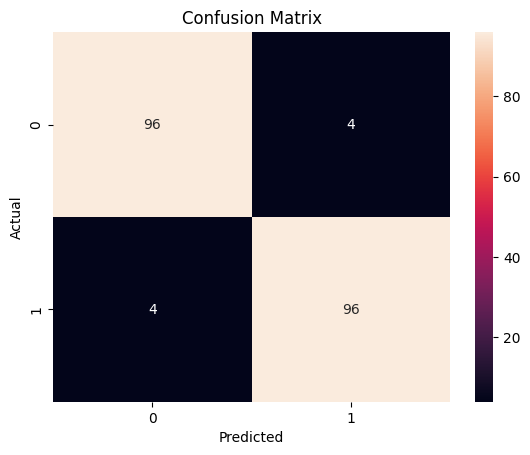

In [14]:
sns.heatmap(cm, annot=True, fmt='g')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [15]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.96      0.96       100
           1       0.96      0.96      0.96       100

    accuracy                           0.96       200
   macro avg       0.96      0.96      0.96       200
weighted avg       0.96      0.96      0.96       200



In [16]:
from sklearn.metrics import precision_score

print("Precision:", precision_score(y_test, y_pred))

Precision: 0.96


In [17]:
from sklearn.metrics import roc_auc_score, roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_probability)

auc = roc_auc_score(y_test, y_probability)

print("AUC:", auc)

AUC: 0.9869


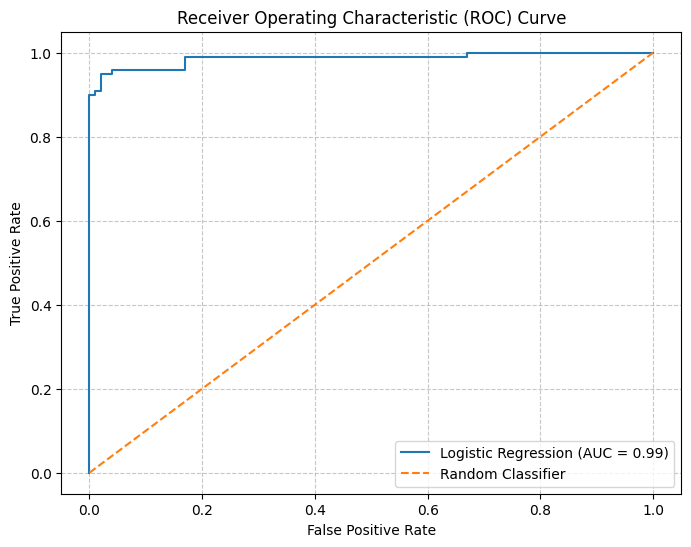

In [18]:
plt.figure(figsize=(8, 6))

plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc:.2f})")

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend()
plt.grid(linestyle='--', alpha=0.7)

plt.show()

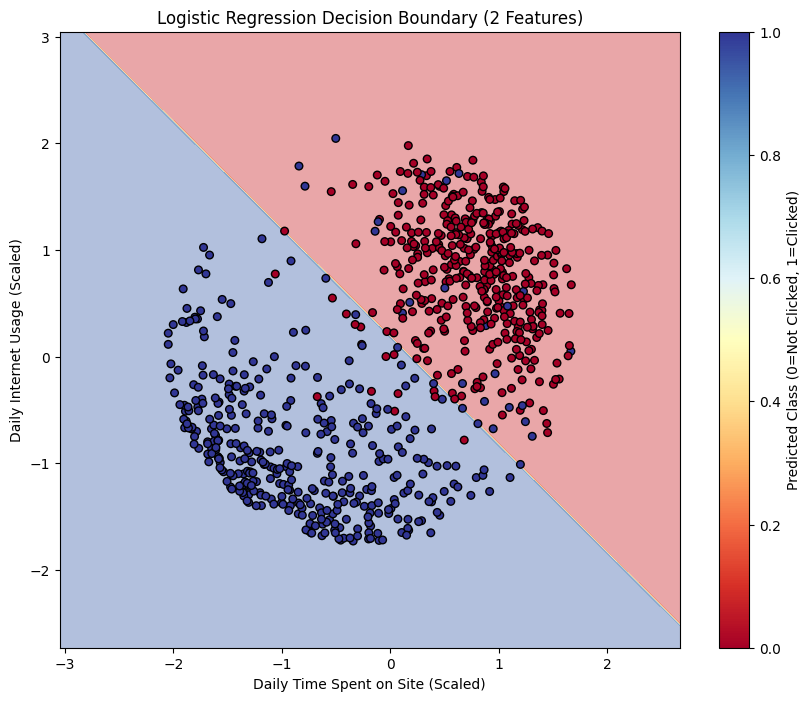

In [19]:
x_min, x_max = X_train_scaled[:, 0].min() - 1, X_train_scaled[:, 0].max() + 1
y_min, y_max = X_train_scaled[:, 1].min() - 1, X_train_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

grid_points = np.c_[xx.ravel(), yy.ravel()]

Z = model.predict(grid_points)

Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 8))

plt.contourf(xx, yy, Z, alpha=0.4, cmap='RdYlBu')

plt.scatter(
    X_train_scaled[:, 0],
    X_train_scaled[:, 1],
    c=y_train,
    s=30,
    edgecolor='k',
    cmap='RdYlBu'
)

plt.xlabel("Daily Time Spent on Site (Scaled)")
plt.ylabel("Daily Internet Usage (Scaled)")
plt.title("Logistic Regression Decision Boundary (2 Features)")

plt.colorbar(label="Predicted Class (0=Not Clicked, 1=Clicked)")

plt.show()

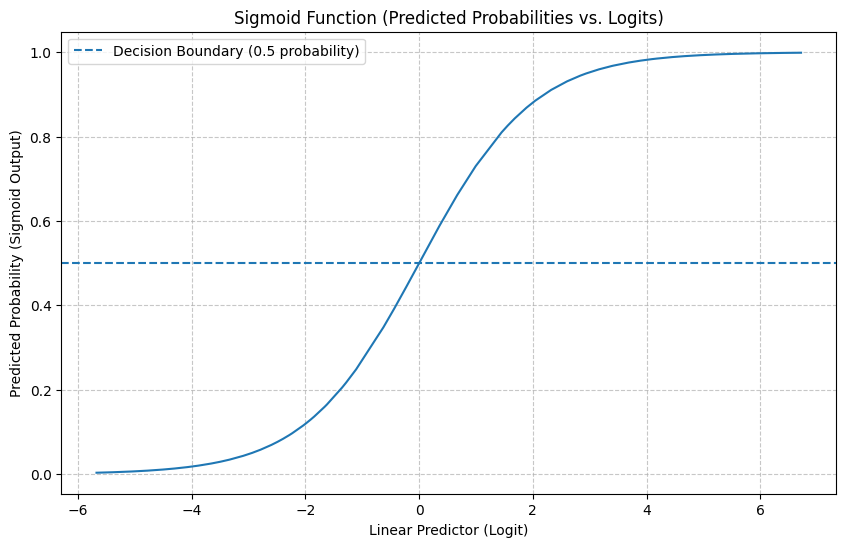

In [20]:
logits = X_test_scaled @ model.coef_.T + model.intercept_

sorted_indices = np.argsort(logits.flatten())

sorted_logits = logits.flatten()[sorted_indices]

sorted_probabilities = y_probability[sorted_indices]

plt.figure(figsize=(10, 6))

plt.plot(sorted_logits, sorted_probabilities)

plt.xlabel("Linear Predictor (Logit)")
plt.ylabel("Predicted Probability (Sigmoid Output)")
plt.title("Sigmoid Function (Predicted Probabilities vs. Logits)")

plt.grid(True, linestyle='--', alpha=0.7)

plt.axhline(
    0.5,
    linestyle='--',
    label='Decision Boundary (0.5 probability)'
)

plt.legend()
plt.show()